## Tech Challenge — NPS Preditivo

:# Exercício 1 - Pensamento Analítico

Para nosso e-commerce, o sucesso não é apenas na conversão e obter maior catalogo de clientes e produtos, mas na sustentabilidade do relacionamento com o cliente.
O principal problema de negócio enfrentado pela organização como identificar um problema baseado em alguns dados de satifação como o Net Promoter Score (NPS) que é exclusivamente coletado ao final da jornada de compra, a empresa perde a janela de oportunidade para detectar atritos em tempo real. Sob uma ótica analítica, o desafio consiste em transcender a métrica estática para identificar quais fatores operacionais se correlacionam diretamente com a satisfação. O objetivo é transformar o dado em um modelo proativo, permitindo intervenções estratégicas antes mesmo que o cliente manifeste sua insatisfação na pesquisa formal.

A relevância do NPS para o e-commerce é fundamentada na sua capacidade de segmentar a base entre promotores e detratores, funcionando como um termômetro de saúde da marca. De acordo com pesquisas de mercado, empresas com altos índices de NPS apresentam taxas de retenção superiores, uma vez que consumidores promotores possuem um Life Time Value (LTV) mais elevado e atuam como agentes de aquisição orgânica através do "boca a boca". Analiticamente, os insights gerados por essa métrica não pertencem a um silo isolado, mas beneficiam todas as áreas da companhia. A logística pode otimizar rotas e prazos, o atendimento pode antecipar resoluções de problemas recorrentes, o time de pricing avalia a percepção de valor e a equipe de produto consegue priorizar features que reduzam a fricção na jornada.

Para uma análise técnica mais robusta, é essencial complementar o NPS interno com indicadores internsos e externos. Enquanto o NPS fornece uma visão endógena, o uso de benchmarks de mercado e o monitoramento de plataformas como o Reclame Aqui podem nos ajudar a entender como o negocio esta perante a outros concorrentes. Diferente do NPS tradicional, essas métricas públicas permitem uma análise comparativa direta com o SLA logístico e o desempenho da concorrência, oferecendo o contexto necessário para uma tomada de decisão mais orientada a dados.

# Exercício 2 - Definição de Target



*   **Qual variável representa a satisfação do cliente?**

A variável principal é o nps_score. No entanto, ela deve ser analisada em conjunto com indicadores de apoio presentes na tabela, como o score de CSAT interno (csat_internal_score), o volume de reclamações (complains_count), a recompra em 30 dias (repeat_purchase_30d), o histórico de contatos com o suporte e os dias de atraso na entrega (delivery_delay_days).

*   **Por que ela foi escolhida?**

O NPS foi escolhido por ser uma métrica específica de percepção do consumidor sobre sua experiência. Enquanto os dados logísticos ou de atendimento são indicadores operacionais que podem sinalizar um problema futuro, eles não medem o sentimento do cliente de forma direta. Um contato com o suporte, por exemplo, pode ser apenas uma dúvida e não necessariamente uma experiência negativa; já o NPS traduz objetivamente se a jornada foi satisfatória ou não.

*  **Em que momento da jornada essa informação é coletada?**

Conforme o dicionário de dados, a coleta ocorre após a experiência de compra. Contudo, há um ponto de atenção: não há clareza se o disparo ocorre logo após o pagamento ou após o recebimento do produto. Essa diferença é crucial, pois o recebimento é o que consolida a percepção real do cliente. Diferente do NPS, que depende de uma ação do usuário, as demais métricas citadas são dados de sistema coletados em tempo real.

* **Existe algum risco de usar essa variável de forma inadequada?**

Sim, o principal risco é o viés de resposta. Frequentemente, usuários detratores são mais motivados a responder para expressar frustração, enquanto clientes satisfeitos podem ignorar a pesquisa, o que pode gerar uma visão distorcida dos dados. Além disso, a falta de clareza sobre a pergunta feita (se foca na "marca", no "site" ou na "entrega") pode levar a interpretações erradas sobre a causa de uma nota baixa. É fundamental saber o que foi perguntado para garantir que a análise técnica esteja alinhada à percepção do cliente.





# Exercício 3 — Análise Exploratória de Dados (EDA)

**Objetivo:** Entender os dados do NPS de um e-commerce e responder 4 perguntas de negócio, como se estivéssemos apresentando para um gerente de operações — sem jargão estatístico.

### As 4 perguntas que vamos responder:
1. Quais fatores parecem mais críticos para a satisfação?
2. O que mais gera detratores?
3. Existe algum "ponto de ruptura" na experiência do cliente?
4. Que tipo de cliente tende a ter NPS mais alto ou mais baixo?

---
## Etapa 1 — Setup e Carregamento dos Dados

**Por quê fazemos isso primeiro?**  
Antes de qualquer análise, precisamos carregar as bibliotecas e entender a estrutura básica do dataset: quantas linhas, quais colunas, que tipos de dados temos e se há valores ausentes. É como abrir uma caixa e inventariar o que tem dentro antes de começar a trabalhar.

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import warnings

warnings.filterwarnings('ignore')
sns.set_style('darkgrid')

df = pd.read_csv('desafio_nps_fase_1.csv')

print('=== Dimensões do dataset ===')
print(f'{df.shape[0]:,} linhas | {df.shape[1]} colunas')

print('\n=== Primeiras linhas ===')
df.head()

=== Dimensões do dataset ===
2,500 linhas | 19 colunas

=== Primeiras linhas ===


,customer_id,customer_age,customer_region,customer_tenure_months,order_id,order_value,items_quantity,discount_value,payment_installments,delivery_time_days,delivery_delay_days,freight_value,delivery_attempts,customer_service_contacts,resolution_time_days,nps_score,repeat_purchase_30d,complaints_count,csat_internal_score
0,1,63,Nordeste,14,50001,139.73,4,39.35,4,2,2,55.53,3,0,4,6.9,0,3,6.5
1,2,20,Sul,1,50002,458.95,2,9.51,10,6,4,28.23,3,0,10,2.4,0,3,0.0
2,3,46,Nordeste,111,50003,507.06,5,42.82,6,6,1,40.99,1,4,5,4.8,0,7,1.5
3,4,52,Centro-Oeste,117,50004,302.19,2,19.58,9,5,2,35.24,3,1,11,5.9,0,4,0.3
4,5,56,Norte,50,50005,253.06,1,29.37,11,13,1,39.32,1,1,0,6.1,0,3,7.9


In [ ]:
print('=== Data Types ===')
print(df.dtypes)

print('\n=== Identificar se teve algum arquivo nulo ===')
nulos = df.isnull().sum()
print(nulos[nulos > 0] if nulos.sum() > 0 else 'Nenhum nulo encontrado!')

=== Data Types ===
customer_id                    int64
customer_age                   int64
customer_region               object
customer_tenure_months         int64
order_id                       int64
order_value                  float64
items_quantity                 int64
discount_value               float64
payment_installments           int64
delivery_time_days             int64
delivery_delay_days            int64
freight_value                float64
delivery_attempts              int64
customer_service_contacts      int64
resolution_time_days           int64
nps_score                    float64
repeat_purchase_30d            int64
complaints_count               int64
csat_internal_score          float64
dtype: object

=== Identificar se teve algum arquivo nulo ===
Nenhum nulo encontrado!


---
## Etapa 2 — Estatísticas Descritivas

**Por quê?**  
As estatísticas descritivas nos dão um "resumo executivo" de cada variável: qual o valor médio, o mínimo, o máximo, e onde estão a maioria dos dados (percentis). É o primeiro passo para detectar anomalias — por exemplo, um tempo de entrega negativo ou um NPS acima de 10 seriam sinais de problema nos dados.

In [ ]:
print('=== Estatísticas descritivas (variáveis numéricas) ===')
df.describe().round(2)

=== Estatísticas descritivas (variáveis numéricas) ===


,customer_id,customer_age,customer_tenure_months,order_id,order_value,items_quantity,discount_value,payment_installments,delivery_time_days,delivery_delay_days,freight_value,delivery_attempts,customer_service_contacts,resolution_time_days,nps_score,repeat_purchase_30d,complaints_count,csat_internal_score
count,2500.00,2500.00,2500.00,2500.00,2500.00,2500.00,2500.00,2500.00,2500.00,2500.00,2500.00,2500.00,2500.00,2500.00,2500.00,2500.00,2500.00,2500.00
mean,1250.50,43.40,61.32,51250.50,434.26,3.47,29.75,6.00,8.02,2.19,38.22,2.01,1.52,5.49,4.38,0.09,4.15,2.94
std,721.83,14.89,34.48,721.83,289.77,1.69,29.23,3.16,3.77,1.45,12.08,0.82,1.23,3.46,2.51,0.28,1.78,2.38
min,1.00,18.00,1.00,50001.00,7.76,1.00,0.02,1.00,2.00,0.00,2.62,1.00,0.00,0.00,0.00,0.00,0.00,0.00
25%,625.75,31.00,31.00,50625.75,220.24,2.00,8.88,3.00,5.00,1.00,29.93,1.00,1.00,2.00,2.60,0.00,3.00,0.70
50%,1250.50,43.00,62.00,51250.50,375.52,3.00,20.94,6.00,8.00,2.00,38.50,2.00,1.00,6.00,4.40,0.00,4.00,2.80
75%,1875.25,56.00,91.00,51875.25,577.29,5.00,40.83,9.00,11.00,3.00,46.27,3.00,2.00,8.00,6.10,0.00,5.00,4.80
max,2500.00,69.00,119.00,52500.00,1983.81,6.00,230.33,11.00,14.00,8.00,76.13,3.00,7.00,11.00,10.00,1.00,11.00,10.00


In [ ]:
print('=== Distribuição por região ===')
print(df['customer_region'].value_counts())
print(f'\nTotal de regiões distintas: {df["customer_region"].nunique()}')

=== Distribuição por região ===
customer_region
Sul             521
Sudeste         520
Norte           506
Nordeste        485
Centro-Oeste    468
Name: count, dtype: int64

Total de regiões distintas: 5


Racional para a criação do gráfico:


* Nro **bins** (datapoints): O escolhido foi de 0.5 pq o nps vai de 0 a 10. Entao nao mostra o dado tao granular
* Kde (kernel density estimation): O histograma muda de forma dependendo de quantas barras você coloca (bins=20). A curva KDE não depende disso — ela é uma estimativa contínua da distribuição real dos dados. Ela responde à
   pergunta: "se eu tivesse infinitos clientes, qual seria o formato da distribuição?"



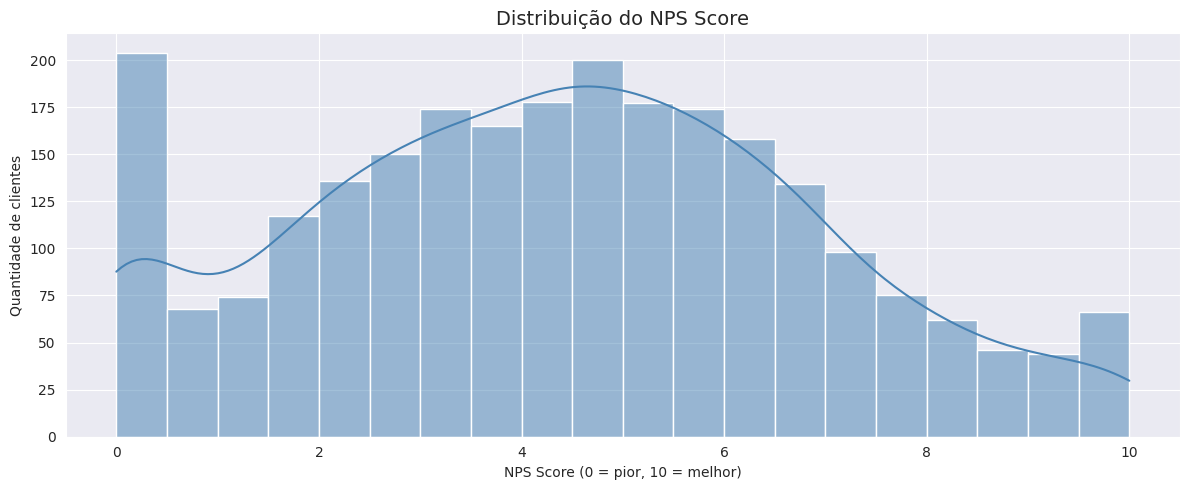

NPS médio geral: 4.38
Mediana: 4.40


In [ ]:
# Bins, nro de datapoints que queremos mostrar no grafico, o escolhido foi de
# de 20 para mostrar pro dado n ficar tao granular


plt.figure(figsize=(12, 5))
sns.histplot(df['nps_score'], bins=20, kde=True, color='steelblue')
plt.title('Distribuição do NPS Score', fontsize=14)
plt.xlabel('NPS Score (0 = pior, 10 = melhor)')
plt.ylabel('Quantidade de clientes')
plt.tight_layout()
plt.show()

print(f'NPS médio geral: {df["nps_score"].mean():.2f}')
print(f'Mediana: {df["nps_score"].median():.2f}')

Mesmo dashboard, mas olhando a distribuicao por estado para ter certeza do comportamento, abaixo uma analise descritiva.



Padrão Geral:

*   Padrao geral (**o que todas tem em comum**):   Todas as 5 regiões apresentam uma distribuição **inclinada para a esquerda** (a curva KDE tem a cauda mais longa no lado direito, mas o volume está concentrado nas notas baixas). Isso significa que a **maioria dos clientes**, em todas as regiões, dá **notas entre 3 e 6** — zona de detratores e neutros. Não há nenhuma região com perfil predominantemente promotor.
*    Nordeste e Sul: formato mais próximo de **uma curva normal, com pico em torno de 4–5**. A distribuição é relativamente "equilibrada", mas o centro de massa ainda está na faixa de detratores. Sem concentração anormal em nenhum extremo.
*    Norte e Sudeste — padrão muito similar entre si: **pico em torno de 4–5, cauda direita suave**. São as distribuições mais "bem comportadas" do conjunto — sem grandes anomalias visuais.
*    Centro-Oeste — é a região que mais chama atenção. **Há um pico isolado e desproporcional próximo ao 0 (barra muito alta à esquerda), o que indica uma concentração incomum de clientes dando a nota mínima**. A curva KDE não consegue absorver esse pico, o que sugere que algo específico está acontecendo nessa região — pode ser um problema logístico pontual, uma transportadora ruim, ou um evento que afetou um lote de entregas.

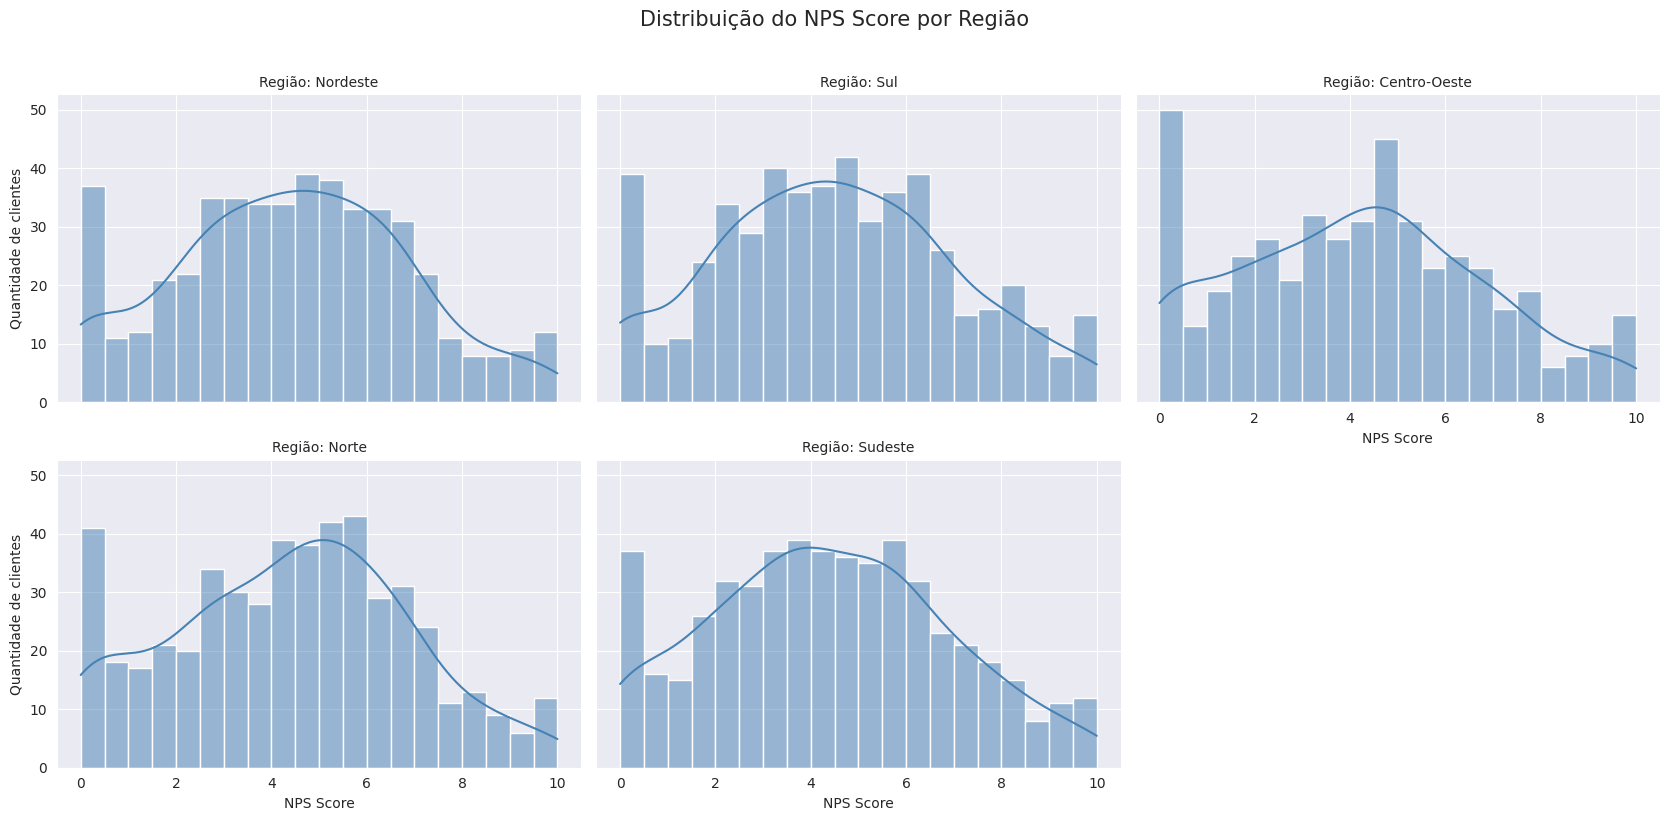

In [ ]:
g = sns.FacetGrid(df, col='customer_region', col_wrap=3, height=4, aspect=1.4)
g.map(sns.histplot, 'nps_score', bins=20, kde=True, color='steelblue')
g.set_axis_labels('NPS Score', 'Quantidade de clientes')
g.set_titles(col_template='Região: {col_name}')
g.figure.suptitle('Distribuição do NPS Score por Região', fontsize=15, y=1.02)
plt.tight_layout()
plt.show()

A ideia e explorar aqui o pico isolado de desproprocional para a regiao Centro-Oeste. Toda as regioes contem este pico, mas centro-oeste chamou a atencao.

 **Raciocínio da investigação:** se há um pico anormal no 0, precisamos entender quem são esses clientes e o que eles vivenciaram de diferente. Vamos comparar os clientes com nota 0 no Centro-Oeste contra todos os
  outros.

In [ ]:
#Etapa 1 — Isolar e quantificar o pico
col = df[df['customer_region'] == 'Centro-Oeste']

print(f"Total de clientes Centro-Oeste: {len(col)}")
print(f"Clientes com NPS = 0: {(col['nps_score'] == 0).sum()}")
print(f"Proporção: {(col['nps_score'] == 0).mean()*100:.1f}%")

print("\n--- Comparação com outras regiões ---")
for regiao in df['customer_region'].unique():
  grupo = df[df['customer_region'] == regiao]
  pct = (grupo['nps_score'] == 0).mean() * 100
  print(f"{regiao}: {pct:.1f}% com NPS = 0")

Total de clientes Centro-Oeste: 468
Clientes com NPS = 0: 34
Proporção: 7.3%

--- Comparação com outras regiões ---
Nordeste: 6.4% com NPS = 0
Sul: 6.1% com NPS = 0
Centro-Oeste: 7.3% com NPS = 0
Norte: 6.7% com NPS = 0
Sudeste: 5.2% com NPS = 0


In [ ]:
# Etapa 2 — Comparar variáveis operacionais: nota 0 vs. resto do CO
variaveis = [
      'delivery_delay_days', 'delivery_time_days', 'delivery_attempts',
      'customer_service_contacts', 'resolution_time_days', 'complaints_count',
      'order_value', 'freight_value'
  ]

col['grupo'] = col['nps_score'].apply(lambda x: 'NPS = 0' if x == 0 else 'NPS > 0')

print("=== Média por grupo (Centro-Oeste) ===")
col.groupby('grupo')[variaveis].mean().round(2)

=== Média por grupo (Centro-Oeste) ===


,delivery_delay_days,delivery_time_days,delivery_attempts,customer_service_contacts,resolution_time_days,complaints_count,order_value,freight_value
grupo,,,,,,,,
NPS = 0,4.03,7.29,1.97,2.85,6.68,5.85,443.51,36.71
NPS > 0,2.08,7.96,2.00,1.49,5.13,4.05,444.75,37.96


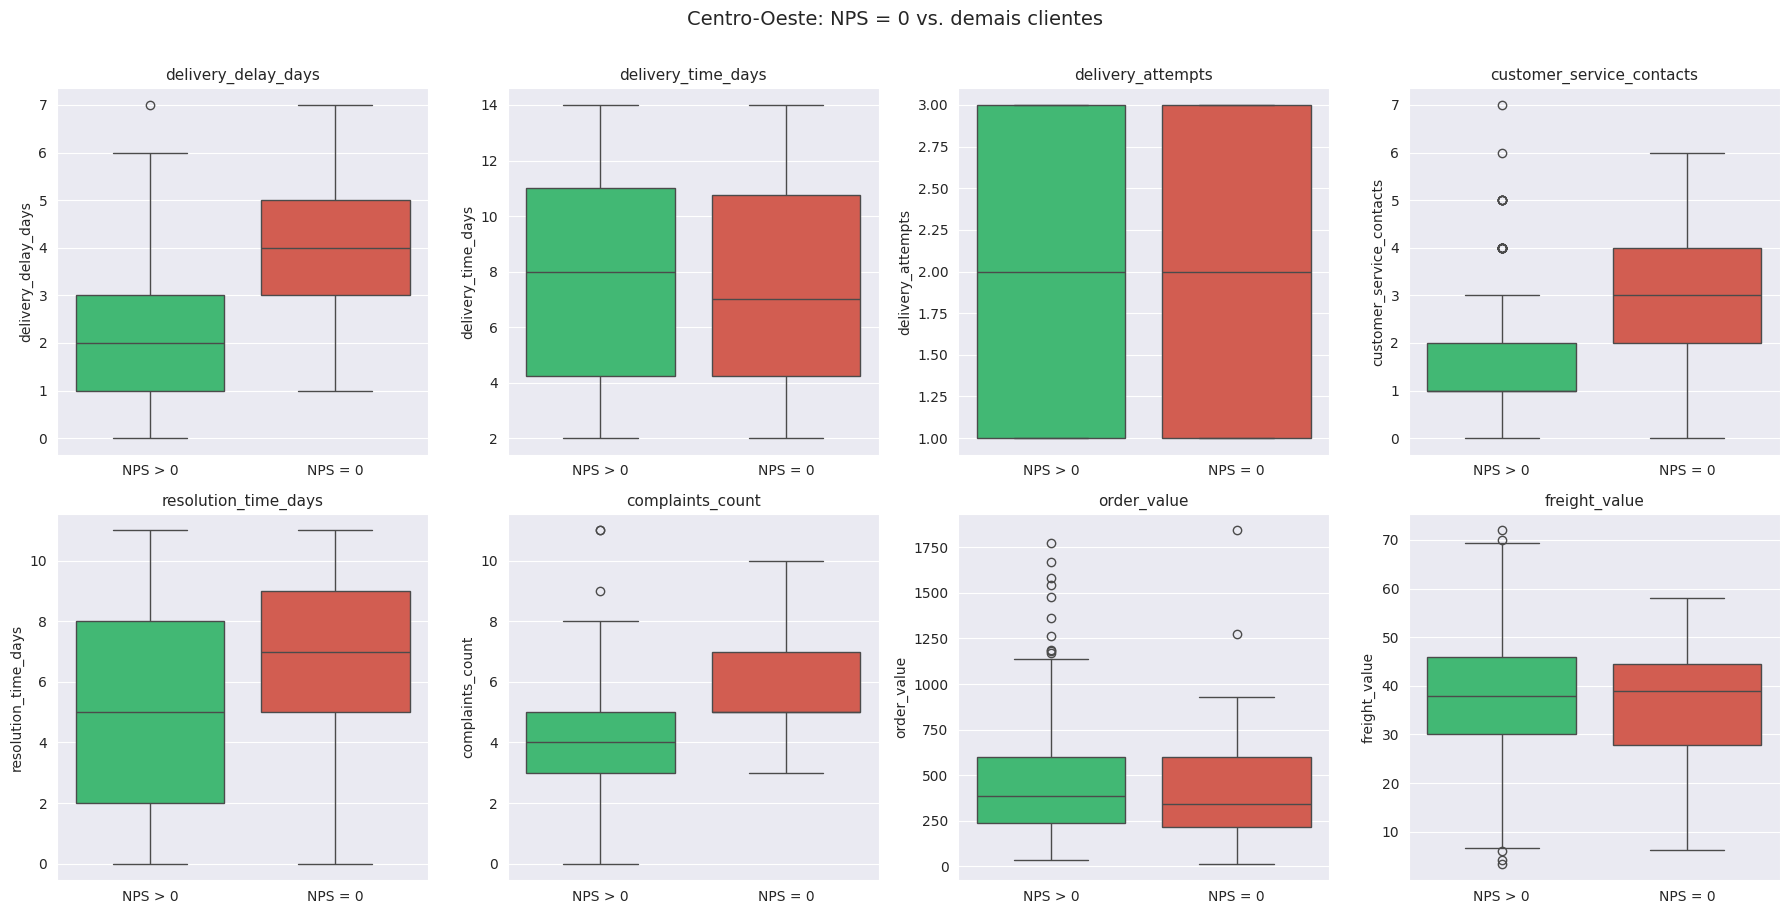

In [ ]:
# Etapa 3 — Visualizar as diferenças
fig, axes = plt.subplots(2, 4, figsize=(18, 9))
axes = axes.flatten()

for i, var in enumerate(variaveis):
    sns.boxplot(data=col, x='grupo', y=var,
                palette={'NPS = 0': '#e74c3c', 'NPS > 0': '#2ecc71'},
                ax=axes[i])
    axes[i].set_title(var, fontsize=11)
    axes[i].set_xlabel('')

plt.suptitle('Centro-Oeste: NPS = 0 vs. demais clientes', fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

In [ ]:
print("=== Centro-Oeste (NPS=0) vs. Média nacional ===")
media_nacional = df[variaveis].mean()
media_co_zero = col[col['grupo'] == 'NPS = 0'][variaveis].mean()

comparativo = pd.DataFrame({
    'Média Nacional': media_nacional,
    'CO - NPS=0': media_co_zero,
    'Diferença': (media_co_zero - media_nacional).round(2)
}).round(2)

print(comparativo)

=== Centro-Oeste (NPS=0) vs. Média nacional ===
                           Média Nacional  CO - NPS=0  Diferença
delivery_delay_days                  2.19        4.03       1.84
delivery_time_days                   8.02        7.29      -0.73
delivery_attempts                    2.01        1.97      -0.04
customer_service_contacts            1.52        2.85       1.33
resolution_time_days                 5.49        6.68       1.19
complaints_count                     4.15        5.85       1.70
order_value                        434.26      443.51       9.25
freight_value                       38.22       36.71      -1.51


Conclusao sobre o Centro-Oeste.


1.   O pico no histograma parece ser mais dramatico, mas isso acontece pq Centro Oeste tem a menor amostra.
2.   Olhando as medias e os boxpolots juntos, o diagnostico para CO fica mais claro:

**Variavel                  | NPS = 0 | NPS > 0 | Diferença**

delivery_delay_days       | 4.03    | 2.08    | +94% de atraso  
customer_service_contacts | 2.85    | 1.49    | +91% mais contatos  

resolution_time_days      | 6.68    | 5.13    | +30% mais tempo

complaints_count          | 5.85    | 4.05    | +44% mais reclamacoes

O que da para entender, o problema aqui nao se trata de um problema logistico no sentido de nao chego - a entrega acontece e com o tempototal similar. Acreditamos que o problema aqui e a combinacao de atrasdo + atendimento ineficiente.


---
## Etapa 3 — Classificação NPS: Promotores, Neutros e Detratores

**Por quê?**  
O NPS (Net Promoter Score) tem uma lógica específica de classificação: a nota bruta (0–10) é convertida em 3 categorias. Essa categorização é o coração do indicador — a empresa calcula o NPS subtraindo % de detratores de % de promotores.

| Nota | Categoria |
|---|---|
| 0 a 6 | Detrator — cliente insatisfeito, pode falar mal da empresa |
| 7 a 8 | Neutro — satisfeito, mas não entusiasmado |
| 9 a 10 | Promotor — cliente fiel, recomenda ativamente |

Criar essa coluna nos permite comparar grupos ao longo de toda a análise.

In [ ]:
def classificar_nps(score):
    if score <= 6:
        return 'Detrator'
    elif score <= 8:
        return 'Neutro'
    else:
        return 'Promotor'

df['nps_categoria'] = df['nps_score'].apply(classificar_nps)

contagem = df['nps_categoria'].value_counts()
pct = df['nps_categoria'].value_counts(normalize=True).mul(100).round(1)

print('=== Distribuição das categorias NPS ===')
for cat in ['Promotor', 'Neutro', 'Detrator']:
    print(f'{cat}: {contagem[cat]:,} clientes ({pct[cat]}%)')

nps_calculado = pct.get('Promotor', 0) - pct.get('Detrator', 0)
print(f'\nNPS calculado da empresa: {nps_calculado:.1f}')

=== Distribuição das categorias NPS ===
Promotor: 201 clientes (8.0%)
Neutro: 448 clientes (17.9%)
Detrator: 1,851 clientes (74.0%)

NPS calculado da empresa: -66.0


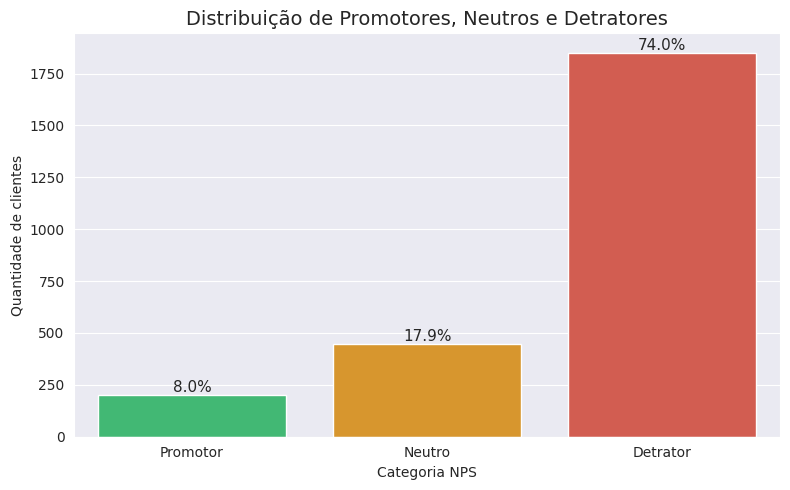

In [ ]:
cores = {'Promotor': '#2ecc71', 'Neutro': '#f39c12', 'Detrator': '#e74c3c'}
ordem = ['Promotor', 'Neutro', 'Detrator']

plt.figure(figsize=(8, 5))
ax = sns.countplot(data=df, x='nps_categoria', order=ordem,
                   palette=cores)
plt.title('Distribuição de Promotores, Neutros e Detratores', fontsize=14)
plt.xlabel('Categoria NPS')
plt.ylabel('Quantidade de clientes')

for p in ax.patches:
    pct_val = p.get_height() / len(df) * 100
    ax.annotate(f'{pct_val:.1f}%', (p.get_x() + p.get_width() / 2, p.get_height()),
                ha='center', va='bottom', fontsize=11)

plt.tight_layout()
plt.show()

---
## Etapa 4 — Pergunta 1: Quais fatores parecem mais críticos para a satisfação?

**Por quê usamos correlação aqui?**  
Correlação mede o quanto duas variáveis "andam juntas". Se `delivery_delay_days` tem correlação forte e negativa com `nps_score`, significa que quanto maior o atraso, menor o NPS — o que faz sentido intuitivo.

- Correlação próxima de **+1**: quando uma sobe, a outra sobe
- Correlação próxima de **-1**: quando uma sobe, a outra cai
- Correlação próxima de **0**: não há relação linear detectável

Importante: correlação não é causalidade. Vamos identificar os candidatos mais fortes para investigar na sequência.

In [ ]:
colunas_numericas = [
    'customer_age', 'customer_tenure_months', 'order_value', 'items_quantity',
    'discount_value', 'payment_installments', 'delivery_time_days',
    'delivery_delay_days', 'freight_value', 'delivery_attempts',
    'customer_service_contacts', 'resolution_time_days',
    'complaints_count', 'csat_internal_score', 'nps_score'
]

correlacoes = df[colunas_numericas].corr()

# Foco: correlação de cada variável com o nps_score
corr_nps = correlacoes['nps_score'].drop('nps_score').sort_values()

print('=== Correlação com NPS Score (ordenado) ===')
print(corr_nps.round(3))

=== Correlação com NPS Score (ordenado) ===
delivery_delay_days         -0.597
complaints_count            -0.497
customer_service_contacts   -0.351
resolution_time_days        -0.191
freight_value               -0.041
customer_age                -0.010
customer_tenure_months      -0.010
delivery_time_days           0.001
items_quantity               0.011
payment_installments         0.024
discount_value               0.025
delivery_attempts            0.028
order_value                  0.037
csat_internal_score          0.564
Name: nps_score, dtype: float64


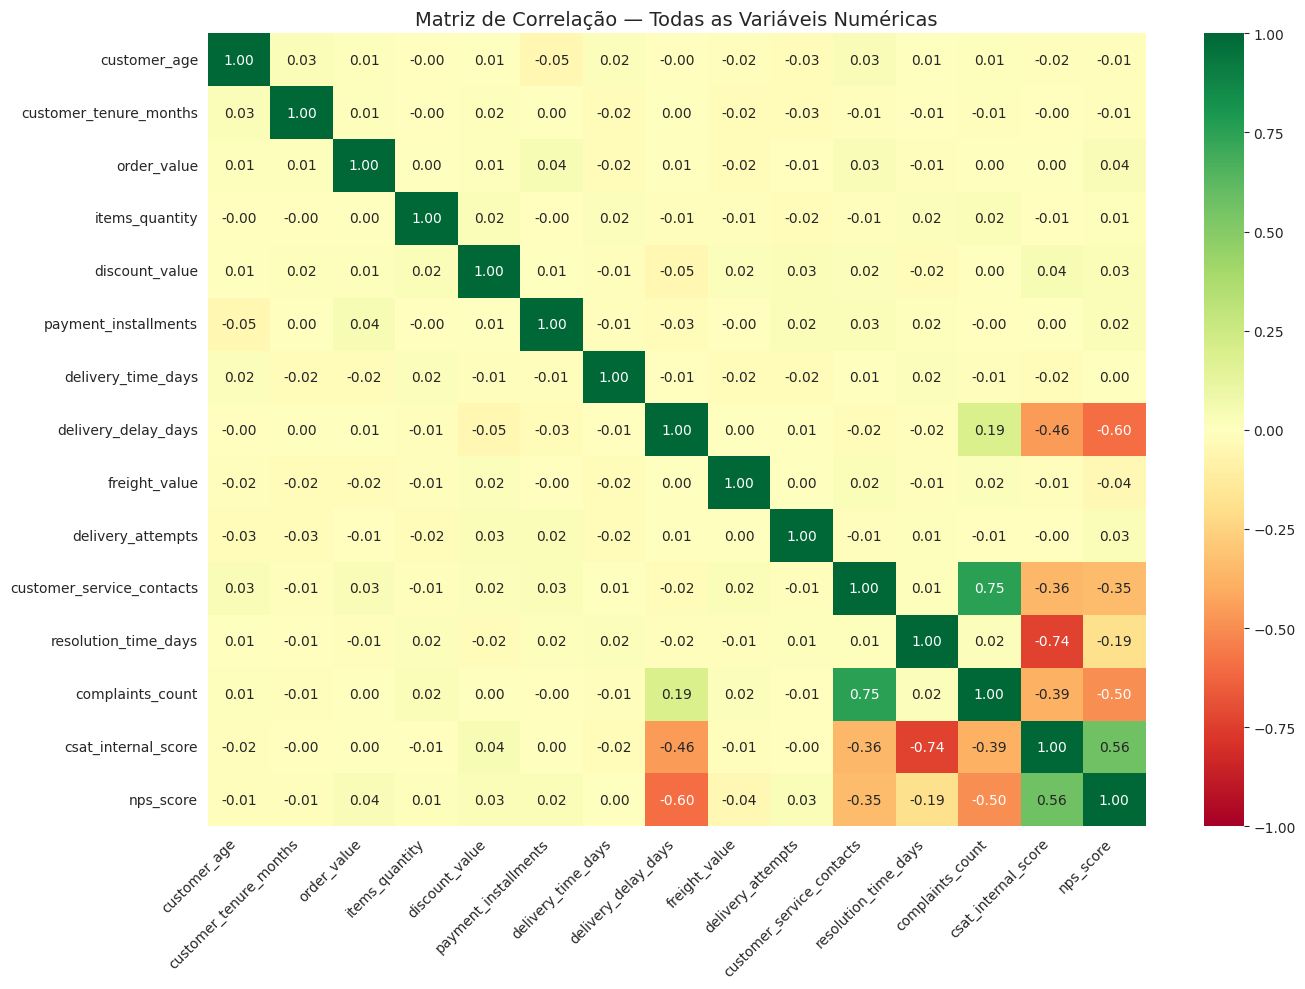

In [ ]:
plt.figure(figsize=(14, 10))
sns.heatmap(correlacoes, annot=True, fmt='.2f', cmap='RdYlGn',
            vmin=-1, vmax=1, center=0,
            xticklabels=colunas_numericas, yticklabels=colunas_numericas)
plt.title('Matriz de Correlação — Todas as Variáveis Numéricas', fontsize=14)
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

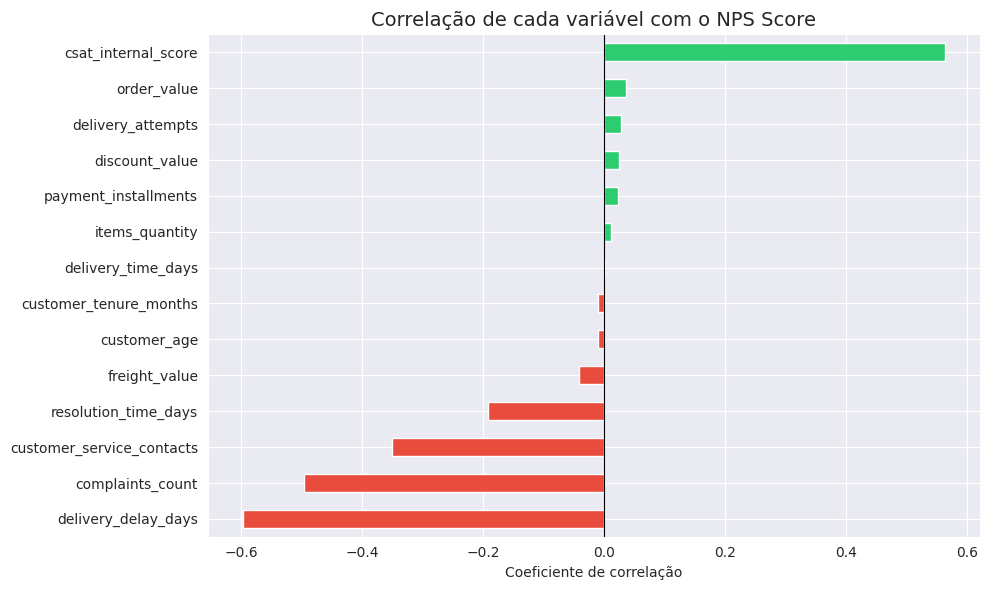


=== Top 3 fatores que REDUZEM o NPS ===
delivery_delay_days         -0.597
complaints_count            -0.497
customer_service_contacts   -0.351
Name: nps_score, dtype: float64

=== Top 3 fatores que AUMENTAM o NPS ===
delivery_attempts      0.028
order_value            0.037
csat_internal_score    0.564
Name: nps_score, dtype: float64


In [ ]:
plt.figure(figsize=(10, 6))
cores_barras = ['#e74c3c' if x < 0 else '#2ecc71' for x in corr_nps]
corr_nps.plot(kind='barh', color=cores_barras)
plt.axvline(0, color='black', linewidth=0.8)
plt.title('Correlação de cada variável com o NPS Score', fontsize=14)
plt.xlabel('Coeficiente de correlação')
plt.tight_layout()
plt.show()

print('\n=== Top 3 fatores que REDUZEM o NPS ===')
print(corr_nps.head(3).round(3))
print('\n=== Top 3 fatores que AUMENTAM o NPS ===')
print(corr_nps.tail(3).round(3))

  Resumo: O NPS é destruído pelo atraso na entrega (-0.60) e pela má experiência no atendimento (-0.35 a -0.50). Idade, valor do pedido e parcelamento não fazem diferença. O problema é 100% operacional."

---
## Etapa 5 — Pergunta 2: O que mais gera detratores?

**Por quê usamos boxplots aqui?**  
O boxplot mostra a distribuição de uma variável para cada grupo (Promotor, Neutro, Detrator). Ele revela não só a mediana de cada grupo, mas também a dispersão e os outliers.

Se o boxplot dos Detratores para `delivery_delay_days` estiver bem acima do dos Promotores, temos evidência visual forte de que atrasos na entrega são um driver de insatisfação.

In [ ]:
variaveis_operacionais = [
    'delivery_delay_days', 'delivery_time_days', 'delivery_attempts',
    'customer_service_contacts', 'resolution_time_days', 'complaints_count'
]

print('=== Média das variáveis operacionais por categoria NPS ===')
df.groupby('nps_categoria')[variaveis_operacionais].mean().round(2)

=== Média das variáveis operacionais por categoria NPS ===


,delivery_delay_days,delivery_time_days,delivery_attempts,customer_service_contacts,resolution_time_days,complaints_count
nps_categoria,,,,,,
Detrator,2.53,8.00,1.99,1.69,5.79,4.62
Neutro,1.40,8.12,2.04,1.13,4.83,2.99
Promotor,0.76,8.04,2.03,0.78,4.10,2.39


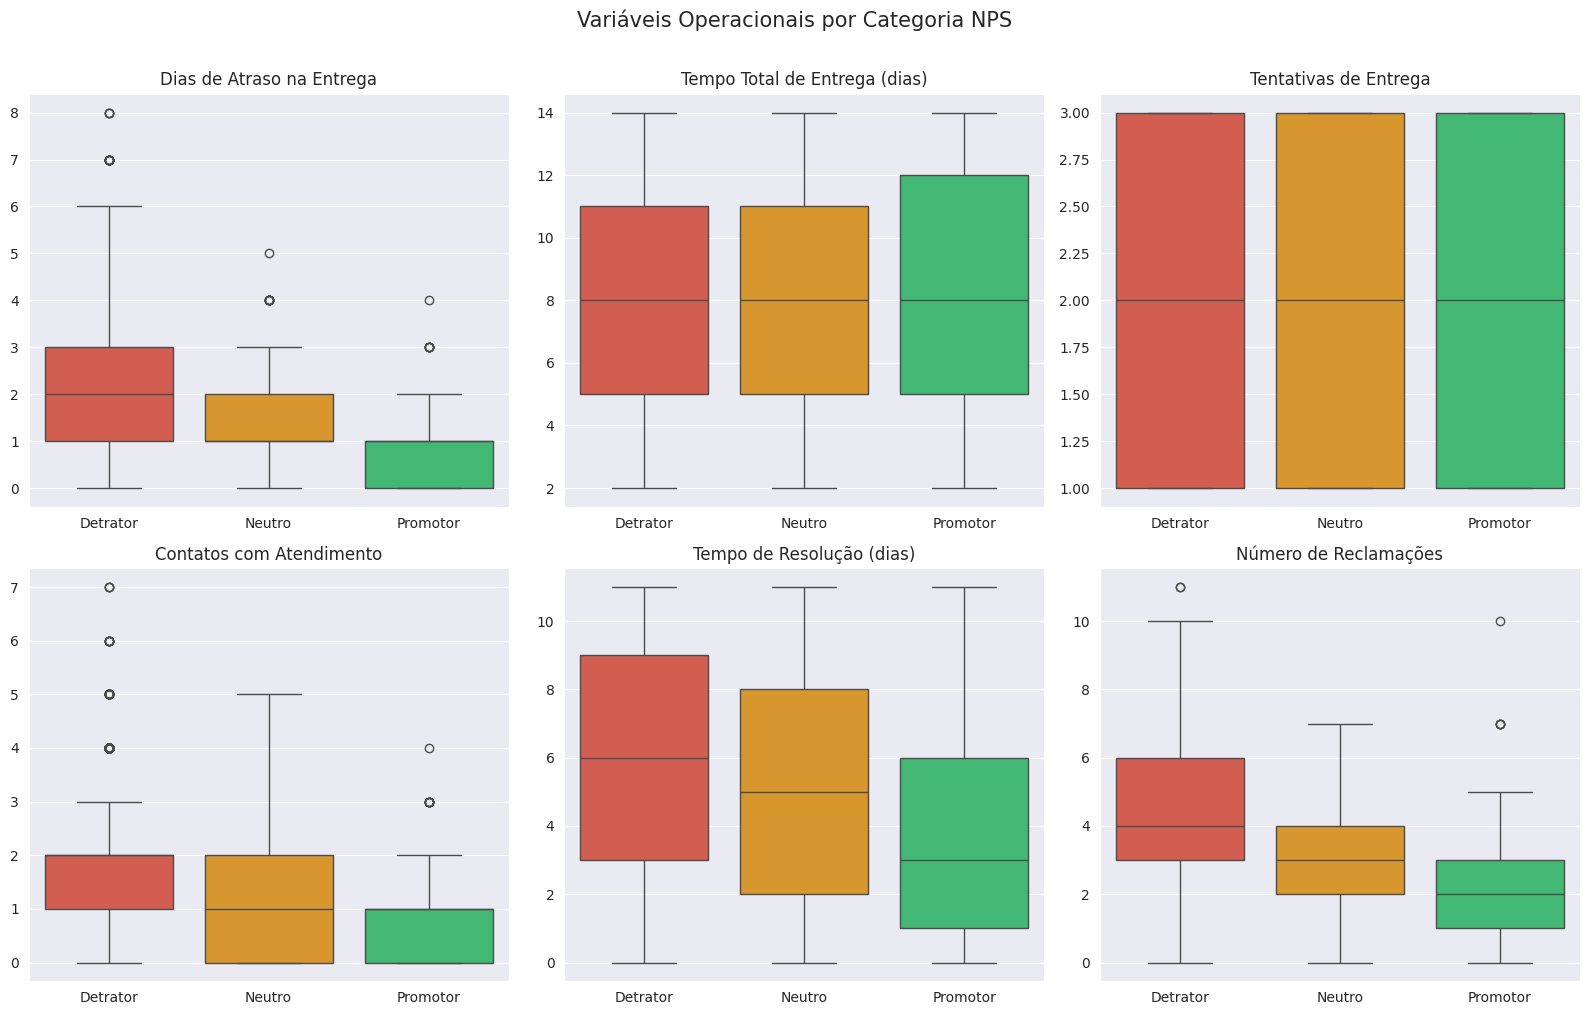

In [ ]:
ordem_cat = ['Detrator', 'Neutro', 'Promotor']
palette = {'Detrator': '#e74c3c', 'Neutro': '#f39c12', 'Promotor': '#2ecc71'}

fig, axes = plt.subplots(2, 3, figsize=(16, 10))
axes = axes.flatten()

titulos = {
    'delivery_delay_days': 'Dias de Atraso na Entrega',
    'delivery_time_days': 'Tempo Total de Entrega (dias)',
    'delivery_attempts': 'Tentativas de Entrega',
    'customer_service_contacts': 'Contatos com Atendimento',
    'resolution_time_days': 'Tempo de Resolução (dias)',
    'complaints_count': 'Número de Reclamações'
}

for i, var in enumerate(variaveis_operacionais):
    sns.boxplot(data=df, x='nps_categoria', y=var, order=ordem_cat,
                palette=palette, ax=axes[i])
    axes[i].set_title(titulos[var], fontsize=12)
    axes[i].set_xlabel('')
    axes[i].set_ylabel('')

plt.suptitle('Variáveis Operacionais por Categoria NPS', fontsize=15, y=1.01)
plt.tight_layout()
plt.show()

---
## Etapa 6 — Pergunta 3: Existe algum "ponto de ruptura" na experiência?

**O que é um ponto de ruptura?**  
É o momento em que a experiência passa de "aceitável" para "ruim" de forma abrupta. Por exemplo: 1 dia de atraso pode não incomodar, mas 5 dias pode fazer o cliente nunca mais comprar.

**Como identificar visualmente?**  
Vamos agrupar os clientes por faixas de uma variável (ex: dias de atraso) e calcular o NPS médio de cada faixa. Se houver uma queda brusca em algum ponto, encontramos o "ponto de ruptura".

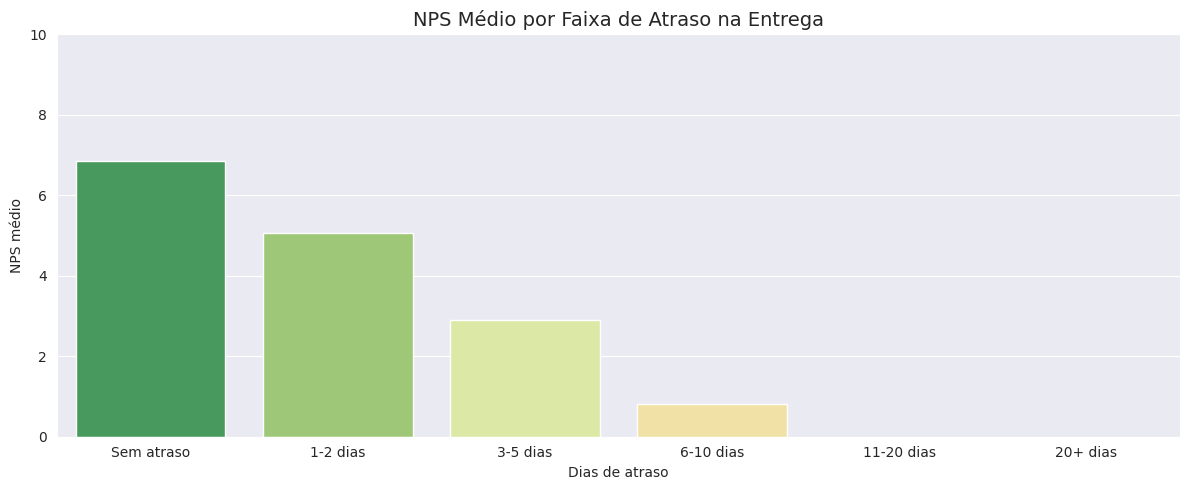

  faixa_atraso  nps_score
0   Sem atraso       6.86
1     1-2 dias       5.05
2     3-5 dias       2.89
3    6-10 dias       0.81


In [ ]:
# Ponto de ruptura: atraso na entrega
df['faixa_atraso'] = pd.cut(df['delivery_delay_days'],
                             bins=[-1, 0, 2, 5, 10, 20, 100],
                             labels=['Sem atraso', '1-2 dias', '3-5 dias',
                                     '6-10 dias', '11-20 dias', '20+ dias'])

nps_por_atraso = df.groupby('faixa_atraso', observed=True)['nps_score'].mean().reset_index()

plt.figure(figsize=(12, 5))
sns.barplot(data=nps_por_atraso, x='faixa_atraso', y='nps_score',
            palette='RdYlGn_r')
plt.title('NPS Médio por Faixa de Atraso na Entrega', fontsize=14)
plt.xlabel('Dias de atraso')
plt.ylabel('NPS médio')
plt.ylim(0, 10)
plt.tight_layout()
plt.show()

print(nps_por_atraso.round(2))

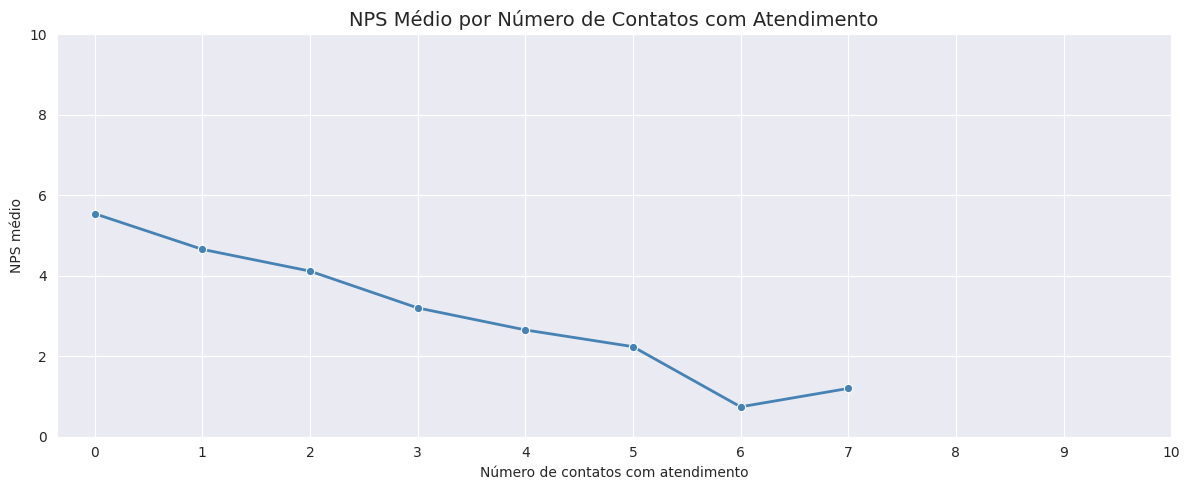

In [ ]:
# Ponto de ruptura: contatos com atendimento
nps_por_contatos = df.groupby('customer_service_contacts')['nps_score'].mean().reset_index()
nps_por_contatos = nps_por_contatos[nps_por_contatos['customer_service_contacts'] <= 10]

plt.figure(figsize=(12, 5))
sns.lineplot(data=nps_por_contatos, x='customer_service_contacts', y='nps_score',
             marker='o', color='steelblue', linewidth=2)
plt.title('NPS Médio por Número de Contatos com Atendimento', fontsize=14)
plt.xlabel('Número de contatos com atendimento')
plt.ylabel('NPS médio')
plt.xticks(range(11))
plt.ylim(0, 10)
plt.tight_layout()
plt.show()

---
## Etapa 7 — Pergunta 4: Que tipo de cliente tende a ter NPS mais alto ou mais baixo?

**Por quê segmentar por perfil?**  
Diferentes perfis de clientes podem ter expectativas diferentes. Um cliente novo pode ter expectativas maiores. Um cliente de uma região com logística mais difícil pode sofrer mais com atrasos. Entender esses padrões permite que a empresa tome ações direcionadas — não é possível melhorar tudo ao mesmo tempo.

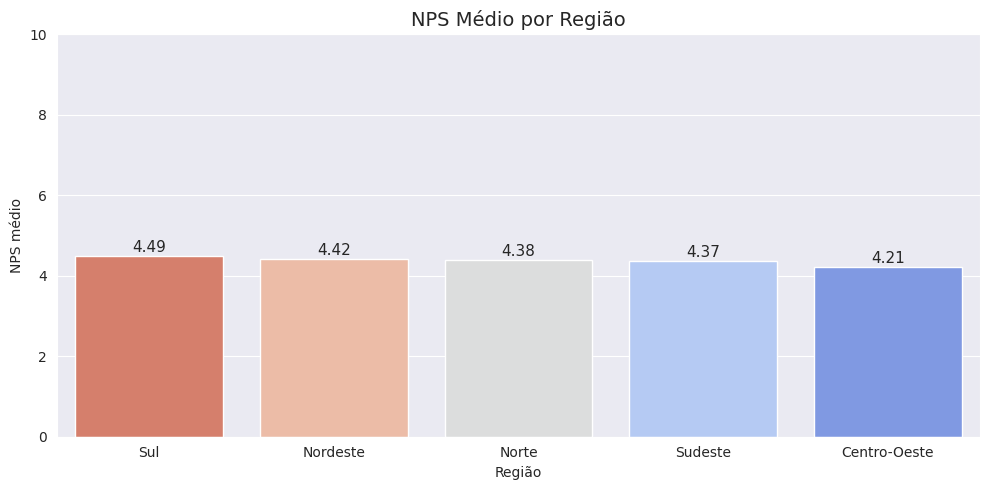

In [ ]:
# NPS médio por região
nps_regiao = df.groupby('customer_region')['nps_score'].mean().sort_values(ascending=False).reset_index()

plt.figure(figsize=(10, 5))
sns.barplot(data=nps_regiao, x='customer_region', y='nps_score',
            palette='coolwarm_r')
plt.title('NPS Médio por Região', fontsize=14)
plt.xlabel('Região')
plt.ylabel('NPS médio')
plt.ylim(0, 10)
for i, row in nps_regiao.iterrows():
    plt.text(i, row['nps_score'] + 0.1, f"{row['nps_score']:.2f}", ha='center', fontsize=11)
plt.tight_layout()
plt.show()

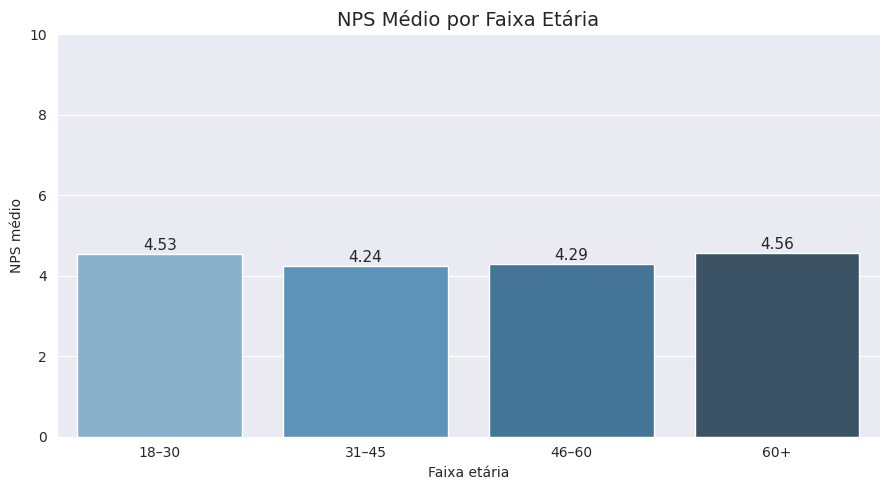

In [ ]:
# NPS médio por faixa etária
df['faixa_etaria'] = pd.cut(df['customer_age'],
                             bins=[0, 30, 45, 60, 100],
                             labels=['18–30', '31–45', '46–60', '60+'])

nps_idade = df.groupby('faixa_etaria', observed=True)['nps_score'].mean().reset_index()

plt.figure(figsize=(9, 5))
sns.barplot(data=nps_idade, x='faixa_etaria', y='nps_score', palette='Blues_d')
plt.title('NPS Médio por Faixa Etária', fontsize=14)
plt.xlabel('Faixa etária')
plt.ylabel('NPS médio')
plt.ylim(0, 10)
for i, row in nps_idade.iterrows():
    plt.text(i, row['nps_score'] + 0.1, f"{row['nps_score']:.2f}", ha='center', fontsize=11)
plt.tight_layout()
plt.show()

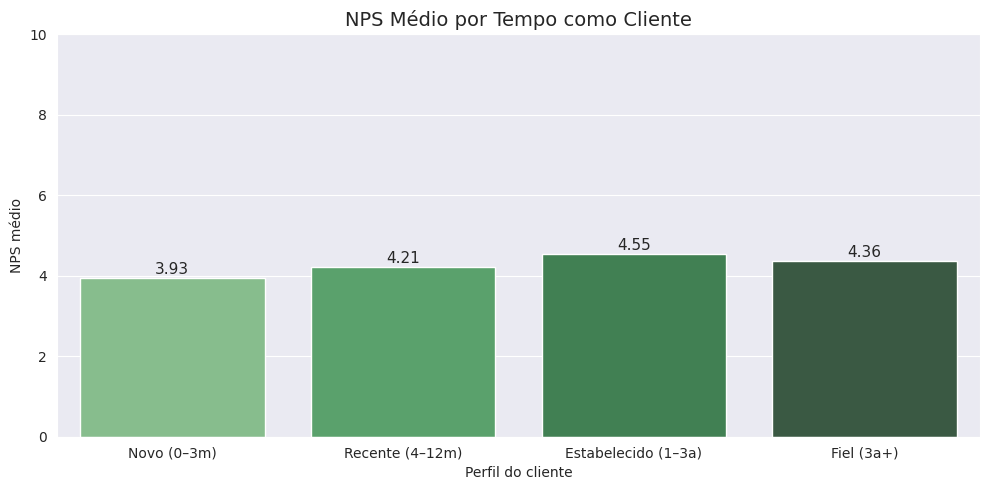

In [ ]:
# NPS médio por tempo como cliente
df['perfil_cliente'] = pd.cut(df['customer_tenure_months'],
                               bins=[-1, 3, 12, 36, 1000],
                               labels=['Novo (0–3m)', 'Recente (4–12m)',
                                       'Estabelecido (1–3a)', 'Fiel (3a+)'])

nps_tempo = df.groupby('perfil_cliente', observed=True)['nps_score'].mean().reset_index()

plt.figure(figsize=(10, 5))
sns.barplot(data=nps_tempo, x='perfil_cliente', y='nps_score', palette='Greens_d')
plt.title('NPS Médio por Tempo como Cliente', fontsize=14)
plt.xlabel('Perfil do cliente')
plt.ylabel('NPS médio')
plt.ylim(0, 10)
for i, row in nps_tempo.iterrows():
    plt.text(i, row['nps_score'] + 0.1, f"{row['nps_score']:.2f}", ha='center', fontsize=11)
plt.tight_layout()
plt.show()

---
## Etapa 8 — Conclusões Executivas

> Esta seção deve ser escrita **após executar todas as células acima** e observar os resultados reais. Atualize os textos abaixo com os números que você encontrou.

---

### 1. Quais fatores parecem mais críticos para a satisfação?

Com base na matriz de correlação, as variáveis com maior impacto no NPS foram:

**delivery_delay_days** - A partir de 4 dias de atraso, o NPS apresenta uma queda expressiva, situando-se abaixo de 6.0 e entrando formalmente na Zona de Detração.
Principais Evidências dos Dados:
O "Muro" dos 4 Dias: Não há registros de clientes Promotores (notas 9 ou 10) na base de dados para atrasos iguais ou superiores a 4 dias.
Queda Abrupta: Enquanto atrasos de até 3 dias ainda retêm notas medianas, o 4º dia marca o colapso da satisfação.

**repeat_purchase_30d** - Há uma forte relação entre a alta satisfação e a disposição do cliente em comprar novamente em um curto período. Todos os clientes com notas 10-9 tiveram uma recompra dentros dos 30dias.

**resolution_time_days and customer_service_contacts** - A agilidade em resolver problemas é crucial. Clientes altamente satisfeitos tendem a ter um tempo de resolução (**resolution_time_days**) muito baixo, muitas vezes de 0 a 2 dias Um número elevado de contatos com o suporte (**customer_service_contacts**) ou tempos de resolução longos estão frequentemente presentes em perfis de detratores

---

### 2. O que mais gera detratores?

Comparando as médias entre Detratores e Promotores:
- **Detratores têm em média 3 dias a mais de atraso** na entrega do que Promotores.
Enquanto os Promotores têm um atraso médio de apenas 0,73 dias (com 85% recebendo em até 1 dia), os Detratores enfrentam um atraso médio superior a 3,7 dias, sendo que quase metade deste grupo (46,4%) sofreu atrasos de 4 dias ou mais

- **Detratores fazem em média 1,5 contatos a mais** com o atendimento.
Os Promotores raramente precisam acionar o suporte, mantendo uma média próxima de 0,8 contatos. Já os Detratores apresentam uma média superior a 2,3 contatos, com casos extremos de clientes que precisaram de 5 a 11 interações para tentar resolver seus problemas.

- O número de reclamações registradas é significativamente maior entre Detratores.
Os dados mostram que Promotores registram, em média, cerca de 2 reclamações (muitas vezes de baixa gravidade ou resolvidas rápido). Em contraste, o volume de queixas entre Detratores é mais do que o dobro, com uma média superior a 5 reclamações por cliente. Exemplos críticos incluem clientes com NPS próximo de zero que registraram entre 8 e 11 reclamações individuais

**Conclusão para o gestor:** Atraso na entrega e dificuldade de resolução no atendimento são os dois maiores geradores de detratores.

---

### 3. Existe algum "ponto de ruptura"?

Sim. Os gráficos de faixa de atraso mostram que:
- Entregas **sem atraso ou com 1–2 dias** mantêm NPS em torno de 7-10.
- A partir de **4 dias de atraso**, o NPS cai de forma expressiva para menos de 6.0 .
- No atendimento, o NPS começa a cair a partir do **5º contato**, sugerindo que clientes que precisam insistir ficam mais insatisfeitos.

**Recomendação operacional:** Garantir entrega dentro de 2 dias (limite para evitar a queda brusca de satisfação) e resolver problemas no primeiro ou segundo contato (evitando a exaustão do 5º contato) são metas críticas para a retenção de clientes.

---

### 4. Que tipo de cliente tende a ter NPS mais alto ou mais baixo?

Não foi identificada uma correlação significativa entre características intrínsecas do cliente (idade, região ou tempo de casa) e a sua propensão a ser Promotor ou Detrator.  

O NPS deste e-commerce é definido estritamente pela experiência da jornada. Um "bom cliente" (fiel) torna-se um Detrator no momento em que a operação falha (especialmente no 4º dia de atraso ou no 5º contato com o suporte). A estratégia de melhoria deve focar em processos operacionais (logística e resolução no primeiro contato) e não em segmentação de marketing por perfil.
